<a href="https://colab.research.google.com/github/Bhagyashree-784/Bhagyashree-784/blob/main/StudentScorePredict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
data = {
'Student_ID': range(1, 101),
'Study_Hours': np.random.uniform(1, 10, 100),
'Attendance': np.random.uniform(50, 100, 100),
'Previous_Marks': np.random.uniform(40, 95, 100),
'Internal_Marks': np.random.uniform(10, 30, 100),
'Final_Result': np.random.choice(['Pass', 'Fail'], 100)
}
df = pd.DataFrame(data)
df.head()

,Student_ID,Study_Hours,Attendance,Previous_Marks,Internal_Marks,Final_Result
0,1,5.818254,89.407052,65.603609,11.587501,Pass
1,2,5.623333,68.033841,57.531175,19.103874,Fail
2,3,3.426747,85.199859,45.137990,21.256404,Pass
3,4,3.638814,89.273826,62.412800,12.272968,Pass
4,5,1.164388,75.336498,89.248852,24.311987,Fail


In [ ]:
df.isnull().sum()

,0
Student_ID,0
Study_Hours,0
Attendance,0
Previous_Marks,0
Internal_Marks,0
Final_Result,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Student_ID      100 non-null    int64  
 1   Study_Hours     100 non-null    float64
 2   Attendance      100 non-null    float64
 3   Previous_Marks  100 non-null    float64
 4   Internal_Marks  100 non-null    float64
 5   Final_Result    100 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 4.8+ KB


In [ ]:

le = LabelEncoder()
df['Final_Result'] = le.fit_transform(df['Final_Result'])
df


,Student_ID,Study_Hours,Attendance,Previous_Marks,Internal_Marks,Final_Result
0,1,1.785482,51.016926,85.147233,11.959014,1
1,2,3.303877,83.165318,53.538079,24.791135,1
2,3,4.368981,61.098852,44.160995,10.376848,0
3,4,7.200879,79.956889,78.387748,24.110726,1
4,5,5.823287,68.199760,90.412218,21.771766,0
...,...,...,...,...,...,...
95,96,2.693963,82.424032,46.435346,19.882947,1
96,97,3.347226,72.114808,56.596991,16.080240,1
97,98,3.378660,90.230428,60.929743,26.984132,1
98,99,9.331085,98.102990,67.094568,27.796906,0


In [ ]:
df['Final_Result'].value_counts()

,count
Final_Result,
1,51
0,49


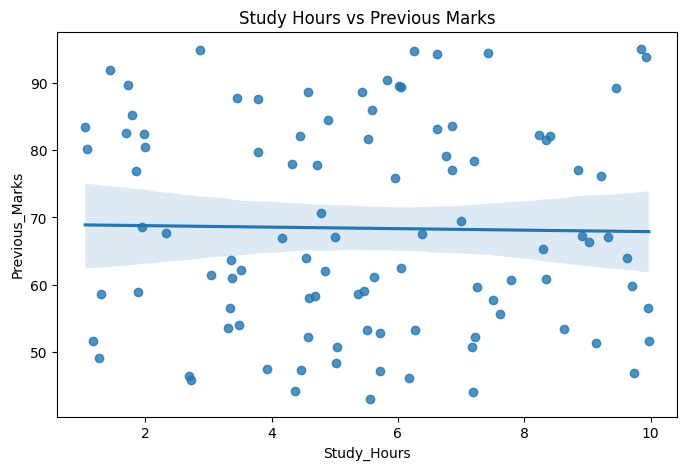

In [ ]:
plt.figure(figsize=(8, 5))
sns.regplot(x='Study_Hours', y='Previous_Marks', data=df)
plt.title('Study Hours vs Previous Marks')
plt.show()

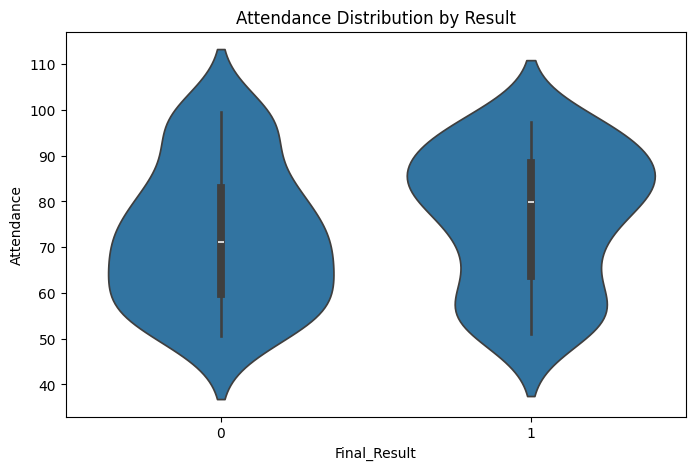

In [ ]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='Final_Result', y='Attendance', data=df)
plt.title('Attendance Distribution by Result')
plt.show()

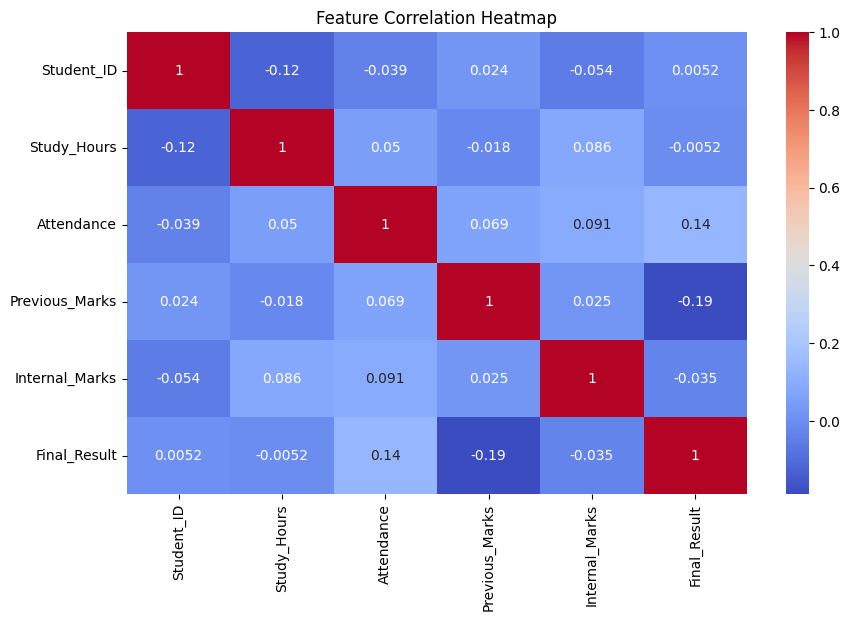

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
X = df.drop(['Student_ID', 'Final_Result'], axis=1)
y = df['Final_Result']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC()
}
results = {}

print(" Model Performance ")
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = accuracy_score(y_test, y_pred)
    print(f"\n{name}:\n{classification_report(y_test, y_pred)}")

 Model Performance 

Logistic Regression:
              precision    recall  f1-score   support

           0       0.57      0.73      0.64        11
           1       0.50      0.33      0.40         9

    accuracy                           0.55        20
   macro avg       0.54      0.53      0.52        20
weighted avg       0.54      0.55      0.53        20


Decision Tree:
              precision    recall  f1-score   support

           0       0.62      0.73      0.67        11
           1       0.57      0.44      0.50         9

    accuracy                           0.60        20
   macro avg       0.59      0.59      0.58        20
weighted avg       0.60      0.60      0.59        20


Naive Bayes:
              precision    recall  f1-score   support

           0       0.42      0.45      0.43        11
           1       0.25      0.22      0.24         9

    accuracy                           0.35        20
   macro avg       0.33      0.34      0.34        20
we

In [ ]:
new=(5,1.551328,62.596255,63.459231,22.930568)
new=(1.551328,62.596255,63.459231,22.930568)
n=np.asarray(new)
n_reshape=n.reshape(1,-1)
prediction=model.predict(n_reshape)
n_scaled = scaler.transform(n_reshape)
prediction=model.predict(n_scaled)
prediction

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0])

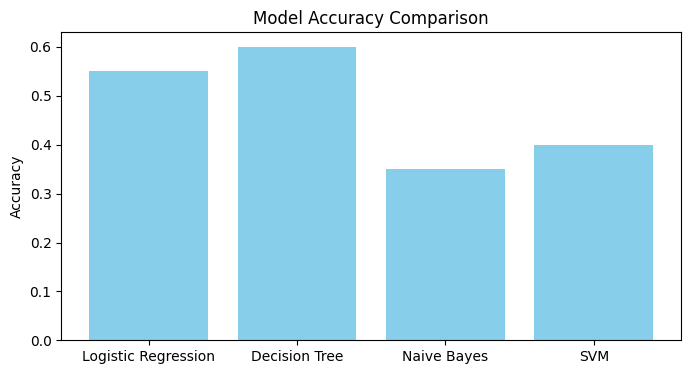

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(results.keys(), results.values(), color='skyblue')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
final_model = DecisionTreeClassifier().fit(X_train, y_train)
df['Predicted_Result'] = final_model.predict(scaler.transform(df[X.columns]))
at_risk_students = df[df['Predicted_Result'] == 0]

In [ ]:
print("\n--- At-Risk Students List ---")
print(at_risk_students[['Student_ID', 'Predicted_Result']])


--- At-Risk Students List ---
    Student_ID  Predicted_Result
0            1                 0
2            3                 0
4            5                 0
8            9                 0
11          12                 0
13          14                 0
14          15                 0
15          16                 0
20          21                 0
22          23                 0
26          27                 0
27          28                 0
29          30                 0
30          31                 0
31          32                 0
35          36                 0
36          37                 0
37          38                 0
38          39                 0
39          40                 0
41          42                 0
43          44                 0
46          47                 0
47          48                 0
49          50                 0
50          51                 0
51          52                 0
53          54                 0
55          